# Lab 3 — BI2013a с линейным SVM (адаптированный вариант)



In [1]:
!pip -q install moabb

In [2]:
import os, sys, logging
from pathlib import Path

import mne
import numpy as np
import torch
from moabb.datasets import BI2013a

sys.path.append(os.path.abspath(".."))
os.environ.setdefault("MPLCONFIGDIR", "outputs/mpl_cache")
os.makedirs("outputs/mpl_cache", exist_ok=True)

from src.models.svm import SVM

mne.set_log_level("WARNING")
logging.getLogger("mne").setLevel(logging.WARNING)

In [3]:
import shutil
try:
    from distutils.dir_util import copy_tree as _copy_tree
    if not hasattr(shutil, 'copy_tree'):
        shutil.copy_tree = _copy_tree
except Exception as ex:
    print('copy_tree patch failed:', ex)


In [4]:
def find_target_ids(event_id: dict):
    lower = {k.lower(): v for k, v in event_id.items()}
    tgt = [k for k in lower if "target" in k and "non" not in k]
    non = [k for k in lower if "non" in k and "target" in k]
    if tgt and non:
        return lower[tgt[0]], lower[non[0]]
    vals = sorted(set(event_id.values()))
    if len(vals) >= 2:
        return vals[-1], vals[0]
    raise RuntimeError(f"Cannot infer target/non-target from {event_id}")


def prep_raw(raw: mne.io.BaseRaw, l_freq: float = 1.0, h_freq: float = 20.0, sfreq: int = 128):
    raw = raw.copy().load_data()
    raw.pick_types(eeg=True, eog=False)
    raw.filter(l_freq, h_freq, verbose=False)
    raw.set_eeg_reference("average", projection=False, verbose=False)
    raw.resample(sfreq, verbose=False)
    return raw


def epochs_to_matrix(raw: mne.io.BaseRaw, tmin: float = -0.2, tmax: float = 0.8, baseline=(None, 0), decim: int = 2):
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    tgt, non = find_target_ids(event_id)
    epochs = mne.Epochs(raw, events, event_id={"Target": tgt, "NonTarget": non},
                        tmin=tmin, tmax=tmax, baseline=baseline, preload=True, verbose=False)
    X = epochs.get_data()[:, :, ::decim]
    y = (epochs.events[:, 2] == tgt).astype(np.float32)
    X = X.reshape(X.shape[0], -1).astype("float32")
    return X, y


def collect(ds: BI2013a, subject_ids):
    feats, labels = [], []
    nested = ds.get_data(subject_ids)
    for sessions in nested.values():
        for runs in sessions.values():
            for raw in runs.values():
                raw_p = prep_raw(raw)
                X, y = epochs_to_matrix(raw_p)
                if len(y) > 0:
                    feats.append(X)
                    labels.append(y)
    return np.vstack(feats).astype(np.float32), np.hstack(labels).astype(np.float32)


def stratified_split(X, y, val_frac=0.15, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    nvp = max(1, int(len(pos) * val_frac))
    nvn = max(1, int(len(neg) * val_frac))
    val_idx = np.concatenate([
        rng.choice(pos, size=min(nvp, len(pos)), replace=False),
        rng.choice(neg, size=min(nvn, len(neg)), replace=False)
    ])
    mask = np.ones(len(y), dtype=bool)
    mask[val_idx] = False
    tr_idx = np.where(mask)[0]
    return (X[tr_idx], y[tr_idx]), (X[val_idx], y[val_idx])


def standardize_train_val_test(X_train, X_val, X_test):
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True) + 1e-8
    return (X_train - mu) / sd, (X_val - mu) / sd, (X_test - mu) / sd

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
ds = BI2013a(NonAdaptive=True, Adaptive=True, Training=True, Online=True)
train_subjects = [1, 2, 3]
test_subjects  = [4]
print(f"Subjects → train={train_subjects}, test={test_subjects}")

print("Collect TRAIN subjects...")
X_tr_all, y_tr_all = collect(ds, train_subjects)
print("Collect TEST subject...")
X_test, y_test = collect(ds, test_subjects)

(X_train, y_train), (X_val, y_val) = stratified_split(X_tr_all, y_tr_all, val_frac=0.15, rng=np.random.default_rng(42))
print(f"Shapes: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

X_train, X_val, X_test = standardize_train_val_test(X_train, X_val, X_test)

X_train_t = torch.from_numpy(X_train).to(device)
y_train_t = torch.from_numpy(y_train).to(device)
X_val_t   = torch.from_numpy(X_val).to(device)
y_val_t   = torch.from_numpy(y_val).to(device)
X_test_t  = torch.from_numpy(X_test).to(device)
y_test_t  = torch.from_numpy(y_test).to(device)

svm = SVM(learning_rate=1e-3, max_epochs=40, batch_size=2048, C=1.0, device=device)
svm.fit(X_train_t, y_train_t, X_val_t, y_val_t)

val_last = {k: float(v) for k, v in svm.history["val_metrics"][-1].items()} if svm.history["val_metrics"] else {}
test_metrics = {k: float(v) for k, v in svm.score(X_test_t, y_test_t).items()}
print("VAL metrics:", val_last)
print("TEST metrics:", test_metrics)

Subjects → train=[1, 2, 3], test=[4]
Collect TRAIN subjects...
Collect TEST subject...
Shapes: train=(27592, 1040), val=(4868, 1040), test=(11544, 1040)
Epoch 1/40 | loss=0.9873 | train acc=0.6421 f1=0.3560 | val acc=0.6327 f1=0.3397
Epoch 11/40 | loss=0.8560 | train acc=0.7078 f1=0.4092 | val acc=0.7011 f1=0.3930
Epoch 21/40 | loss=0.7718 | train acc=0.7571 f1=0.4511 | val acc=0.7535 f1=0.4398
Epoch 31/40 | loss=0.7008 | train acc=0.8020 f1=0.4929 | val acc=0.7938 f1=0.4671
Epoch 40/40 | loss=0.6455 | train acc=0.8311 f1=0.5164 | val acc=0.8252 f1=0.4944
VAL metrics: {'hinge_loss': 0.6343368291854858, 'accuracy': 0.8251848816871643, 'f1_score': 0.49435529112815857}
TEST metrics: {'hinge_loss': 0.6733138561248779, 'accuracy': 0.8334199786186218, 'f1_score': 0.13728129863739014}


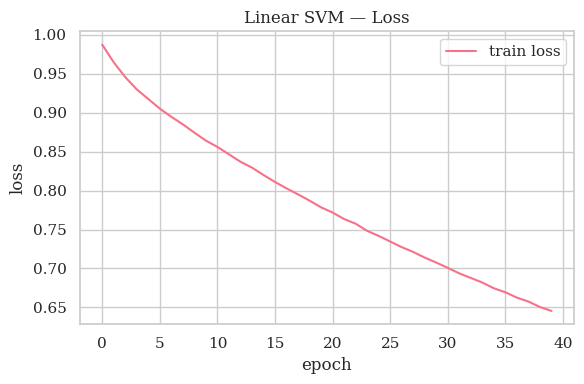

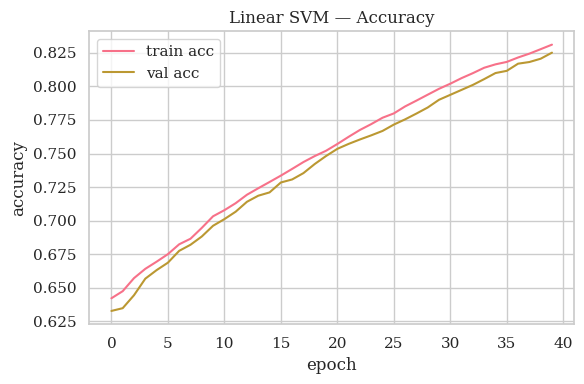

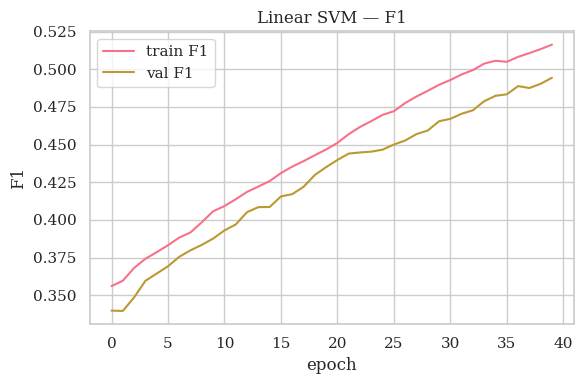

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(svm.history["train_loss"], label="train loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Linear SVM — Loss")
plt.legend(); plt.tight_layout(); plt.show()

tr_acc = [float(m["accuracy"]) for m in svm.history["train_metrics"]]
va_acc = [float(m["accuracy"]) for m in svm.history["val_metrics"]]
plt.figure(figsize=(6,4))
plt.plot(tr_acc, label="train acc")
plt.plot(va_acc, label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Linear SVM — Accuracy")
plt.legend(); plt.tight_layout(); plt.show()

tr_f1 = [float(m["f1_score"]) for m in svm.history["train_metrics"]]
va_f1 = [float(m["f1_score"]) for m in svm.history["val_metrics"]]
plt.figure(figsize=(6,4))
plt.plot(tr_f1, label="train F1")
plt.plot(va_f1, label="val F1")
plt.xlabel("epoch"); plt.ylabel("F1")
plt.title("Linear SVM — F1")
plt.legend(); plt.tight_layout(); plt.show()